In [ ]:
pip install gdown

In [ ]:
import pandas as pd
import json
import os
import glob
import gdown
import os

from dotenv import load_dotenv

load_dotenv(override=True)

id = os.getenv("DRIVE_ID", "")
output = "./datalake/"
gdown.download_folder(id=id, output=output)

In [241]:
def load_json_files(file_paths):
    """
    Load data from multiple JSON files
    
    Args:
    file_paths (list): List of file paths to load
    
    Returns:
    list: Combined data from all files
    """
    all_data = []
    for file_path in file_paths:
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                # handle both json and jsonl formats
                if file_path.endswith('.json'):
                    data = json.load(f)
                else:  # JSONL
                    data = [json.loads(line) for line in f]
                
                # ensure data is a list
                if not isinstance(data, list):
                    data = [data]
                
                all_data.extend(data)
        except Exception as e:
            print(f"Error reading {file_path}: {e}")
    
    return all_data


In [242]:
def process_books(book_data):
    """
    Process book data
    
    Args:
    book_data (list): List of book dictionaries
    
    Returns:
    tuple: Cleaned books, series set, genre set
    """
    cleaned_books = []
    series_set = set()
    genre_set = set()
    
    for book in book_data:
        # handle series as a list or string
        series = book.get('series', '')
        if isinstance(series, list):
            series = series[0] if series else ''
        
        # clean and standardize book data
        cleaned_book = {
            'isbn': book.get('isbn', [''])[0] if isinstance(book.get('isbn'), list) else book.get('isbn', ''),
            'isbn13': book.get('isbn13', [''])[0] if isinstance(book.get('isbn13'), list) else book.get('isbn13', ''),
            'title': book.get('title', ''),
            'image_url': book.get('imageUrl', ''),
            'description': book.get('description', ''),
            'author': book.get('author', ''),
            'num_pages': book.get('numPages', None),
            'language': book.get('language', ''),
            'review_count': book.get('reviewsCount', 0),
            'kindle_price': book.get('ebookPrice', None),
            'publish_date': book.get('publishDate', ''),
            'crawl_source': book.get('crawlSource', ''),
            'average_rating': book.get('averageRating', None),
            'series': series
        }
        
        # track series
        if cleaned_book['series']:
            series_set.add(cleaned_book['series'])
        
        # track genres
        genres = book.get('genres', [])
        if isinstance(genres, list):
            genre_set.update(genres)
        elif isinstance(genres, str):
            genre_set.add(genres)
        
        cleaned_books.append(cleaned_book)
    
    return cleaned_books, series_set, genre_set


In [243]:
def process_reviews(review_data):
    """
    Process review data
    
    Args:
    review_data (list): List of review dictionaries
    
    Returns:
    list: Processed reviews
    """
    reviews = []
    
    for review_set in review_data:
        # handle reviews by book
        if 'rating' in review_set and isinstance(review_set['rating'], list):
            isbn = review_set.get('isbn', [''])[0] if isinstance(review_set.get('isbn'), list) else review_set.get('isbn', '')
            isbn13 = review_set.get('isbn13', [''])[0] if isinstance(review_set.get('isbn13'), list) else review_set.get('isbn13', '')
            
            for rating_entry in review_set['rating']:
                reviews.append({
                    'isbn': isbn,
                    'isbn13': isbn13,
                    'user_id': rating_entry.get('user', None),
                    'rating_score': rating_entry.get('rating', 0)
                })
        
        # handle reviews by user
        elif 'userId' in review_set and 'rating' in review_set:
            user_id = review_set.get('userId', [''])[0] if isinstance(review_set.get('userId'), list) else review_set.get('userId', '')
            
            for rating_entry in review_set['rating']:
                reviews.append({
                    'isbn': rating_entry.get('isbn', ''),
                    'isbn13': rating_entry.get('isbn13', ''),
                    'user_id': user_id,
                    'rating_score': rating_entry.get('rating', 0)
                })
    
    return reviews



In [244]:
def process_users(user_data):
    """
    Process user data
    
    Args:
    user_data (list): List of user dictionaries
    
    Returns:
    list: Processed users
    """
    processed_users = []
    for user in user_data:
        # handle variations in user data structure
        user_id = user.get('userId', [''])[0] if isinstance(user.get('userId'), list) else user.get('userId', '')
        name = user.get('name', [''])[0] if isinstance(user.get('name'), list) else user.get('name', '')
        
        processed_user = {
            'user_id': user_id,
            'name': name,
            'profile_url': user.get('profileUrl', [''])[0] if isinstance(user.get('profileUrl'), list) else user.get('profileUrl', ''),
            'total_ratings': user.get('totalRatings', ['0'])[0] if isinstance(user.get('totalRatings'), list) else user.get('totalRatings', '0'),
            'total_reviews': user.get('totalReviews', ['0'])[0] if isinstance(user.get('totalReviews'), list) else user.get('totalReviews', '0'),
            'avg_rating': user.get('avgRating', ['0'])[0] if isinstance(user.get('avgRating'), list) else user.get('avgRating', '0'),
            'image_url': user.get('imageUrl', [''])[0] if isinstance(user.get('imageUrl'), list) else user.get('imageUrl', '')
        }
        
        processed_users.append(processed_user)
    
    return processed_users



In [245]:
def main(base_directory):
    books_json_files = [
        os.path.join(base_directory, 'goodreads', 'book_group.json'),
        os.path.join(base_directory, 'goodreads', 'data_50000_60000.json'),
        os.path.join(base_directory, 'goodreads', 'data_60001_70000.json'),
        os.path.join(base_directory, 'goodreads', 'data_70001_80000.json'),
        os.path.join(base_directory, 'goodreads', 'data_80001_90000.json'),
        os.path.join(base_directory, 'goodreads/old', 'book_1_10k.json'),
        os.path.join(base_directory, 'goodreads/old', 'books_200000_to_250000.json'),
        # add all book json file paths here
    ]
    
    reviews_json_files = [
        os.path.join(base_directory, 'goodreads', 'review_50000_60000.json'),
        # os.path.join(base_directory, 'goodreads', 'ratings.json'),
        os.path.join(base_directory, 'goodreads/old', 'reviews.jsonl'),
        os.path.join(base_directory, 'goodreads/old', 'reviews_books_200000_to_250000.json'),
        os.path.join(base_directory, 'goodreads/old', 'data_review1_10k.json'),
        os.path.join(base_directory, 'goodreads/old', 'data_review150-155k.json'),
        os.path.join(base_directory, 'goodreads/old', 'data_review155-160k.json'),
        os.path.join(base_directory, 'goodreads/old', 'data_review160-165k.json'),
        os.path.join(base_directory, 'goodreads/old', 'data_review165-170k.json'),
        os.path.join(base_directory, 'goodreads/old', 'data_review170-175k.json'),
        # add all review json file paths here
    ]
    
    users_json_files = [
        os.path.join(base_directory, 'goodreads', 'group_user.json'),
        os.path.join(base_directory, 'goodreads', 'group1.json'),
        os.path.join(base_directory, 'goodreads/old', 'users.jsonl'),
        os.path.join(base_directory, 'goodreads', 'group_user.json'),
        # add all user json file paths here
    ]
    
    # load and process data
    print("Loading book data...")
    book_data = load_json_files(books_json_files)
    print(f"Loaded {len(book_data)} book entries")
    
    print("Processing book data...")
    cleaned_books, series_set, genre_set = process_books(book_data)
    
    print("Loading review data...")
    review_data = load_json_files(reviews_json_files)
    print(f"Loaded {len(review_data)} review entries")
    
    print("Processing review data...")
    reviews = process_reviews(review_data)
    
    print("Loading user data...")
    user_data = load_json_files(users_json_files)
    print(f"Loaded {len(user_data)} user entries")
    
    print("Processing user data...")
    users = process_users(user_data)
    
    # create DataFrames
    books_df = pd.DataFrame(cleaned_books)
    reviews_df = pd.DataFrame(reviews)
    users_df = pd.DataFrame(users)
    
    # series DataFrame
    series_df = pd.DataFrame({
        'series_id': range(1, len(series_set) + 1),
        'name': list(series_set)
    })
    
    # genres DataFrame
    genres_df = pd.DataFrame({
        'genre_id': range(1, len(genre_set) + 1),
        'name': list(genre_set)
    })
    
    # book-genres DataFrame
    book_genres = []
    for book in book_data:
        if book.get('genres'):
            for genre in book.get('genres', []):
                book_genres.append({
                    'isbn': book.get('isbn', [''])[0] if isinstance(book.get('isbn'), list) else book.get('isbn', ''),
                    'isbn13': book.get('isbn13', [''])[0] if isinstance(book.get('isbn13'), list) else book.get('isbn13', ''),
                    'genre_id': genres_df[genres_df['name'] == genre]['genre_id'].values[0]
                })
    book_genres_df = pd.DataFrame(book_genres)


    
    # save to csv
    books_df.to_csv('clean/books.csv', index=False, mode='w')
    series_df.to_csv('clean/series.csv', index=False, mode='w')
    genres_df.to_csv('clean/genres.csv', index=False, mode='w')
    book_genres_df.to_csv('clean/book_genres.csv', index=False, mode='w')
    reviews_df.to_csv('clean/reviews.csv', index=False, mode='w')
    users_df.to_csv('clean/users.csv', index=False, mode='w')
    
    print("CSV files created successfully!")


In [246]:
main('./datalake/book-rec-datalake')

Loading book data...
Loaded 104300 book entries
Processing book data...
Loading review data...
Loaded 52237 review entries
Processing review data...
Loading user data...
Loaded 36670 user entries
Processing user data...
CSV files created successfully!


In [247]:
# with open('./datalake/book-rec-datalake/goodreads/ratings.json', 'r') as f:
#     data = f.read()
# print(data)

df = pd.read_json('./datalake/book-rec-datalake/goodreads/ratings.json')
df

,userId,rating
0,[145704009],"[{'isbn': '1400341124', 'isbn13': '97814003411..."
1,[8829118],"[{'isbn': '0812998626', 'isbn13': '97808129986..."
2,[63113280],"[{'isbn': '', 'isbn13': '9781984829993', 'book..."
3,[160270339],"[{'isbn': '0312642717', 'isbn13': '97803126427..."
4,[103379996],"[{'isbn': '', 'isbn13': '', 'book_href': 'http..."
...,...,...
1574,[107912421],"[{'isbn': '', 'isbn13': '', 'book_href': 'http..."
1575,[167510184],"[{'isbn': '', 'isbn13': '', 'book_href': 'http..."
1576,[92390881],"[{'isbn': '0525539727', 'isbn13': '97805255397..."
1577,[63665211],"[{'isbn': '0063308312', 'isbn13': '97800633083..."


In [248]:
exploded_df = df.explode('userId').reset_index(drop=True)
exploded_df = exploded_df.explode('rating').reset_index(drop=True)
exploded_df

,userId,rating
0,145704009,"{'isbn': '1400341124', 'isbn13': '978140034112..."
1,145704009,"{'isbn': '1662527004', 'isbn13': '978166252700..."
2,145704009,"{'isbn': '1662529376', 'isbn13': '978166252937..."
3,145704009,"{'isbn': '1662529341', 'isbn13': '978166252934..."
4,145704009,"{'isbn': '166252823X', 'isbn13': '978166252823..."
...,...,...
525779,125982174,"{'isbn': '0439554934', 'isbn13': '978043955493..."
525780,125982174,"{'isbn': '0316015849', 'isbn13': '978031601584..."
525781,125982174,"{'isbn': '0062024035', 'isbn13': '978006202403..."
525782,125982174,"{'isbn': '', 'isbn13': '', 'book_href': 'https..."


In [249]:
expanded_df = pd.concat(
    [exploded_df.drop(columns='rating'), pd.json_normalize(exploded_df['rating'])],
    axis=1
)
expanded_df

,userId,isbn,isbn13,book_href,rating
0,145704009,1400341124,9781400341122,https://www.goodreads.com/book/show/200212922-...,5
1,145704009,1662527004,9781662527005,https://www.goodreads.com/book/show/219754771-...,4
2,145704009,1662529376,9781662529375,https://www.goodreads.com/book/show/220389090-...,4
3,145704009,1662529341,9781662529344,https://www.goodreads.com/book/show/220389457-...,4
4,145704009,166252823X,9781662528231,https://www.goodreads.com/book/show/220389455-...,3
...,...,...,...,...,...
525779,125982174,0439554934,9780439554930,https://www.goodreads.com/book/show/3.Harry_Po...,5
525780,125982174,0316015849,9780316015844,https://www.goodreads.com/book/show/41865.Twil...,5
525781,125982174,0062024035,9780062024039,https://www.goodreads.com/book/show/13335037-d...,5
525782,125982174,,,https://www.goodreads.com/book/show/11870085-t...,5


In [250]:
print(f"Unique ISBN_10: {expanded_df['isbn'].nunique()}, ISBN_13: {expanded_df['isbn13'].nunique()}")
print(f"Unique userId: {expanded_df['userId'].nunique()}")

Unique ISBN_10: 141192, ISBN_13: 143252
Unique userId: 1579


In [251]:
df_to_save = expanded_df.rename(columns={
    "userId": "userid",
    "rating": "rating_score"
})

In [252]:
df_to_save.to_csv(
    'clean/reviews.csv',
    mode='a',
    index=False,
    header=not pd.io.common.file_exists('clean/reviews.csv'),
    columns=["isbn", "isbn13", "userid", "rating_score"]
)

In [253]:
ratings_df = pd.read_csv('./clean/reviews.csv', low_memory=False)
null_count = ratings_df['rating_score'].isnull().sum()
non_numeric = pd.to_numeric(ratings_df['rating_score'], errors='coerce')
non_numeric_count = non_numeric.isnull().sum()
non_null_ratings = ratings_df.loc[ratings_df['rating_score'].notnull(), 'rating_score']
truly_non_numeric_count = pd.to_numeric(non_null_ratings, errors='coerce').isnull().sum()
print(f"Total invalid rows: {null_count + truly_non_numeric_count}")

Total invalid rows: 95590


In [254]:
def clean_csv_files(directory, overwrite=False, suffix="_cleaned"):
    """
    Remove rows with missing critical identifiers or exact duplicates from CSV files in the directory.
    
    Args:
        directory (str): Path to the directory containing CSV files.
        overwrite (bool): Whether to overwrite the original files. Defaults to False.
        suffix (str): Suffix for the cleaned files if not overwriting. Defaults to "_cleaned".
    """
    for file_name in os.listdir(directory):
        if file_name.endswith(".csv"):
            file_path = os.path.join(directory, file_name)
            
            try:
                # read the csv file with low_memory=False to handle mixed types
                df = pd.read_csv(file_path, low_memory=False)
                
                original_rows = len(df)
                print(f"\nProcessing {file_name}")
                print(f"Original number of rows: {original_rows}")
                
                # cleaning strategy
                cleaned_df = df.copy()
                
                # check for isbnor isbn13 columns
                isbn_columns = ['isbn', 'isbn13']
                existing_isbn_columns = [col for col in isbn_columns if col in df.columns]
                
                if existing_isbn_columns:
                    # drop rows where isbn, isbn13 columns are missing or empty
                    cleaned_df = cleaned_df[
                        cleaned_df[existing_isbn_columns].notna().any(axis=1) & 
                        (cleaned_df[existing_isbn_columns] != '').any(axis=1)
                    ]
                    
                # rating_score column
                if 'rating_score' in df.columns:
                    cleaned_df = cleaned_df[cleaned_df['rating_score'].notnull()]
                    cleaned_df.loc[:, "rating_score"] = pd.to_numeric(cleaned_df["rating_score"], errors="coerce")
                    cleaned_df = cleaned_df.dropna(subset=['rating_score'])
                    
                    cleaned_df["rating_score"] = cleaned_df["rating_score"].astype(float)
                
                # remove exact duplicates
                duplicates = cleaned_df.duplicated(keep='first')
                duplicate_count = duplicates.sum()
                
                print(f"Duplicate rows found: {duplicate_count}")
                cleaned_df = cleaned_df.drop_duplicates()
                
                # logging final dataset size
                final_rows = len(cleaned_df)
                print(f"Final number of rows: {final_rows}")
                print(f"Rows removed: {original_rows - final_rows} ({((original_rows - final_rows)/original_rows)*100:.2f}%)")
                
                # save cleaned data
                output_file_path = file_path if overwrite else os.path.join(
                    directory, file_name.replace(".csv", f"{suffix}.csv")
                )
                
                cleaned_df.to_csv(output_file_path, index=False)
                print(f"Cleaned file saved to: {output_file_path}")
            
            except Exception as e:
                print(f"Error processing file {file_name}: {e}")

In [255]:
clean_csv_files(directory="./clean", overwrite=True)


Processing reviews.csv
Original number of rows: 1140846
Duplicate rows found: 87439
Final number of rows: 845857
Rows removed: 294989 (25.86%)
Cleaned file saved to: ./clean/reviews.csv

Processing book_genres.csv
Original number of rows: 327542
Duplicate rows found: 8785
Final number of rows: 317790
Rows removed: 9752 (2.98%)
Cleaned file saved to: ./clean/book_genres.csv

Processing users.csv
Original number of rows: 36670
Duplicate rows found: 13078
Final number of rows: 23592
Rows removed: 13078 (35.66%)
Cleaned file saved to: ./clean/users.csv

Processing genres.csv
Original number of rows: 1022
Duplicate rows found: 0
Final number of rows: 1022
Rows removed: 0 (0.00%)
Cleaned file saved to: ./clean/genres.csv

Processing books.csv
Original number of rows: 104300
Duplicate rows found: 1023
Final number of rows: 102561
Rows removed: 1739 (1.67%)
Cleaned file saved to: ./clean/books.csv

Processing series.csv
Original number of rows: 5949
Duplicate rows found: 0
Final number of row

In [259]:
import matplotlib.pyplot as plt
import seaborn as sns

books_df = pd.read_csv('./clean/books.csv', low_memory=False)
reviews_df = pd.read_csv('./clean/reviews.csv',low_memory=False)
series_df = pd.read_csv('./clean/series.csv')
book_genres_df = pd.read_csv('./clean/book_genres.csv')
genres_df = pd.read_csv('./clean/genres.csv')
users_df = pd.read_csv('./clean/users.csv')

In [260]:
print(books_df['average_rating'].unique())
print(books_df['average_rating'].head(20)) 

['[3.71]' '[4.13]' '[2.61]' '[4.34]' '[3.39]' '[3.32]' '[2.81]' '[3.67]'
 '[3.62]' '[4.09]' '[4.66]' '[4.1]' '[3.24]' '[2.94]' '[4.22]' '[3.42]'
 '[3.99]' '[3.79]' '[4.04]' '[4.57]' '[3.57]' '[3.58]' '[3.89]' '[3.95]'
 '[4.19]' '[4.21]' '[3.63]' '[3.97]' '[3.29]' '[4.43]' '[4.2]' '[4.51]'
 '[3.75]' '[3.59]' '[3.86]' '[4.41]' '[4.05]' '[4.03]' '[3.76]' '[3.9]'
 '[3.87]' '[3.91]' '[3.68]' '[4.12]' '[4.18]' '[4.45]' '[4.02]' '[4.39]'
 '[4.16]' '[3.56]' '[3.66]' '[3.93]' '[3.65]' '[3.74]' '[3.43]' '[4.47]'
 '[3.88]' '[3.83]' '[4.65]' '[4.23]' '[4.38]' '[3.82]' '[3.36]' '[3.77]'
 '[3.92]' '[4.31]' '[4.17]' '[3.47]' '[3.98]' '[4.06]' '[3.85]' '[3.16]'
 '[3.8]' '[3.81]' '[3.94]' '[4.01]' '[4.14]' '[3.69]' '[4.11]' '[4.26]'
 '[4.4]' '[3.96]' '[3.61]' '[3.84]' '[4.27]' '[3.72]' '[4.07]' '[4.37]'
 '[4.25]' '[4.15]' '[4.24]' '[4.28]' '[3.1]' '[4.55]' '[4.5]' '[3.7]'
 '[3.6]' '[4.3]' '[4.46]' '[4.63]' '[3.51]' '[4.44]' '[4.53]' '[3.23]'
 '[4.32]' '[3.53]' '[3.48]' '[4.35]' '[4.49]' '[4.61]' '[4.7]

In [261]:
# remove square brackets and strip any extra whitespace
books_df['average_rating'] = books_df['average_rating'].str.strip("[]").str.strip()

# convert to numeric, coercing errors to NaN
books_df['average_rating'] = pd.to_numeric(books_df['average_rating'], errors='coerce')

# drop rows where 'average_rating' is NaN after conversion
books_df = books_df.dropna(subset=['average_rating'])

print(books_df['average_rating'].unique())
print(books_df['average_rating'].head(20))


[3.71 4.13 2.61 4.34 3.39 3.32 2.81 3.67 3.62 4.09 4.66 4.1  3.24 2.94
 4.22 3.42 3.99 3.79 4.04 4.57 3.57 3.58 3.89 3.95 4.19 4.21 3.63 3.97
 3.29 4.43 4.2  4.51 3.75 3.59 3.86 4.41 4.05 4.03 3.76 3.9  3.87 3.91
 3.68 4.12 4.18 4.45 4.02 4.39 4.16 3.56 3.66 3.93 3.65 3.74 3.43 4.47
 3.88 3.83 4.65 4.23 4.38 3.82 3.36 3.77 3.92 4.31 4.17 3.47 3.98 4.06
 3.85 3.16 3.8  3.81 3.94 4.01 4.14 3.69 4.11 4.26 4.4  3.96 3.61 3.84
 4.27 3.72 4.07 4.37 4.25 4.15 4.24 4.28 3.1  4.55 4.5  3.7  3.6  4.3
 4.46 4.63 3.51 4.44 4.53 3.23 4.32 3.53 3.48 4.35 4.49 4.61 4.7  4.08
 3.52 3.78 3.49 4.36 4.58 3.64 4.33 3.55 3.34 4.   3.73 3.5  4.6  4.52
 4.62 2.98 3.33 3.44 4.48 4.75 4.42 4.29 3.4  3.38 3.54 4.54 3.37 3.27
 3.45 3.   3.31 3.28 3.04 3.11 3.15 3.3  4.71 4.67 4.56 4.73 3.03 4.59
 2.43 3.41 3.46 3.18 2.83 3.2  2.71 4.74 2.97 3.05 3.35 3.26 4.76 2.
 5.   2.77 3.12 3.25 4.8  2.69 2.82 3.22 3.08 4.64 2.9  2.76 3.17 3.19
 2.55 3.09 2.57 2.92 2.8  2.72 3.13 3.21 2.65 3.07 3.02 3.14 2.93 2.86
 4.72 3.0

In [262]:
num_books = books_df.shape[0]
num_reviews = reviews_df.shape[0]
unique_users = reviews_df['user_id'].nunique() if 'user_id' in reviews_df.columns else None

reviews_per_user = num_reviews / unique_users if unique_users else None
# reviews_per_book = num_reviews / num_books

# Print statistics
print(f"Number of books: {num_books}")
print(f"Number of reviews: {num_reviews}")
print(f"Number of unique users: {unique_users}")
print(f"Average reviews per user: {reviews_per_user:.2f}" if reviews_per_user else "User data not available")
# print(f"Average reviews per book: {reviews_per_book:.2f}")

Number of books: 102561
Number of reviews: 845857
Number of unique users: 253687
Average reviews per user: 3.33


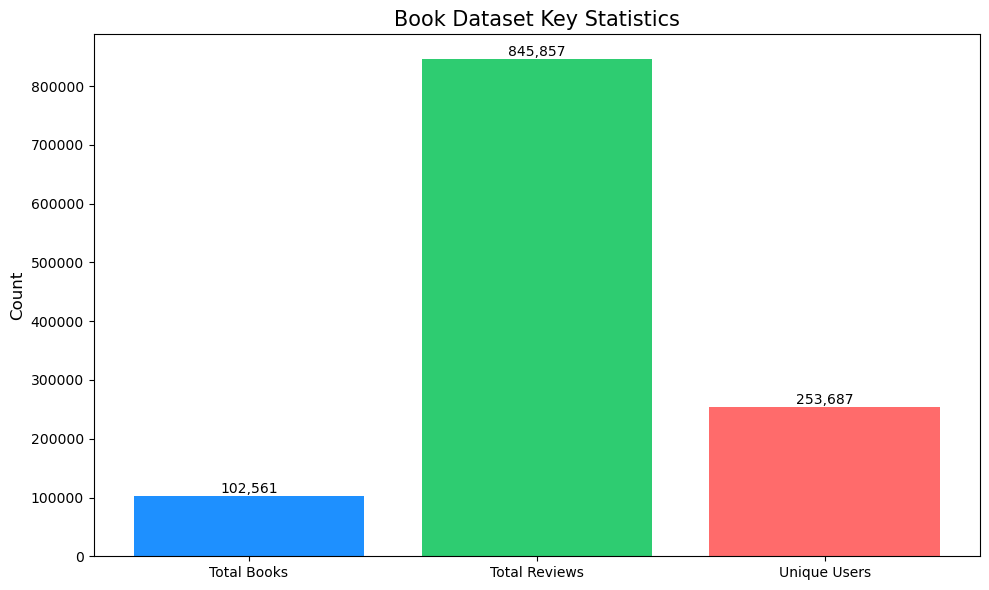

In [263]:
# Create a bar plot to visualize the key statistics
plt.figure(figsize=(10, 6))
stats = [num_books, num_reviews, unique_users]
labels = ['Total Books', 'Total Reviews', 'Unique Users']
colors = ['#1E90FF', '#2ECC71', '#FF6B6B']

plt.bar(labels, stats, color=colors)
plt.title('Book Dataset Key Statistics', fontsize=15)
plt.ylabel('Count', fontsize=12)

# Add value labels on top of each bar
for i, v in enumerate(stats):
    plt.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


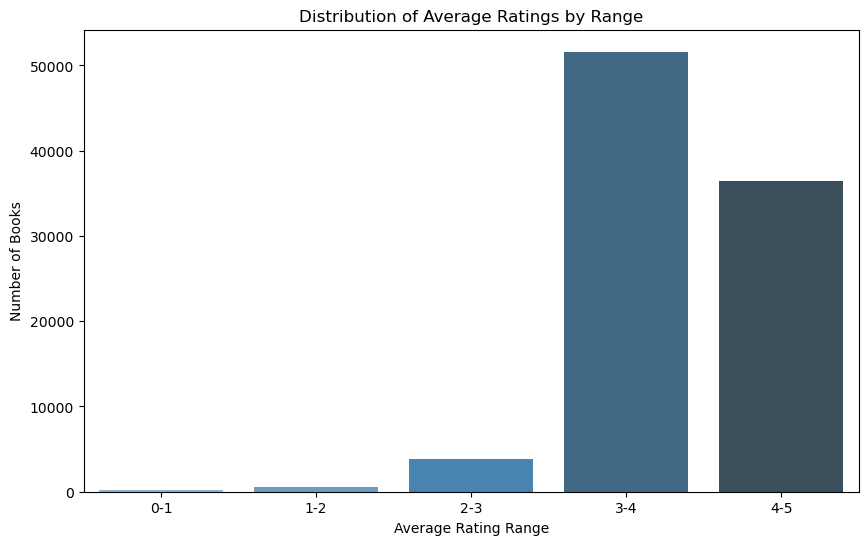

In [264]:
# Create bins for average rating ranges
rating_bins = pd.cut(books_df['average_rating'], bins=[0, 1, 2, 3, 4, 5], labels=['0-1', '1-2', '2-3', '3-4', '4-5'])

# Count the number of books in each bin
rating_range_counts = rating_bins.value_counts().sort_index()

# Plot the grouped data
plt.figure(figsize=(10, 6))
sns.barplot(x=rating_range_counts.index, y=rating_range_counts.values, palette='Blues_d')
plt.title('Distribution of Average Ratings by Range')
plt.xlabel('Average Rating Range')
plt.ylabel('Number of Books')
plt.show()


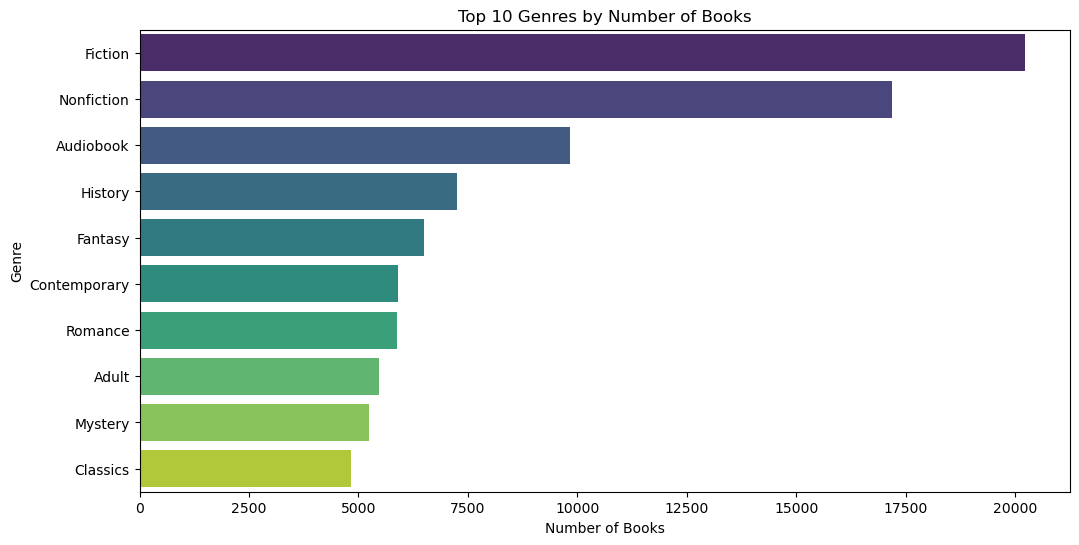

In [265]:
# merge book_genres and genres to get genre names
genre_counts = book_genres_df.merge(genres_df, on='genre_id')['name'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='viridis')
plt.title('Top 10 Genres by Number of Books')
plt.xlabel('Number of Books')
plt.ylabel('Genre')
plt.show()


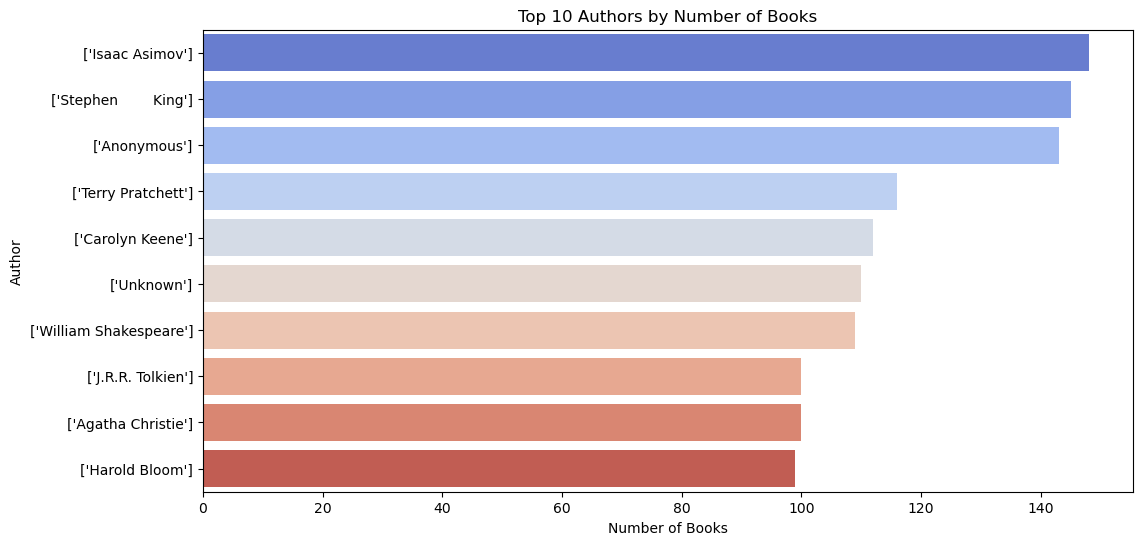

In [266]:
top_authors = books_df['author'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_authors.values, y=top_authors.index, palette='coolwarm')
plt.title('Top 10 Authors by Number of Books')
plt.xlabel('Number of Books')
plt.ylabel('Author')
plt.show()


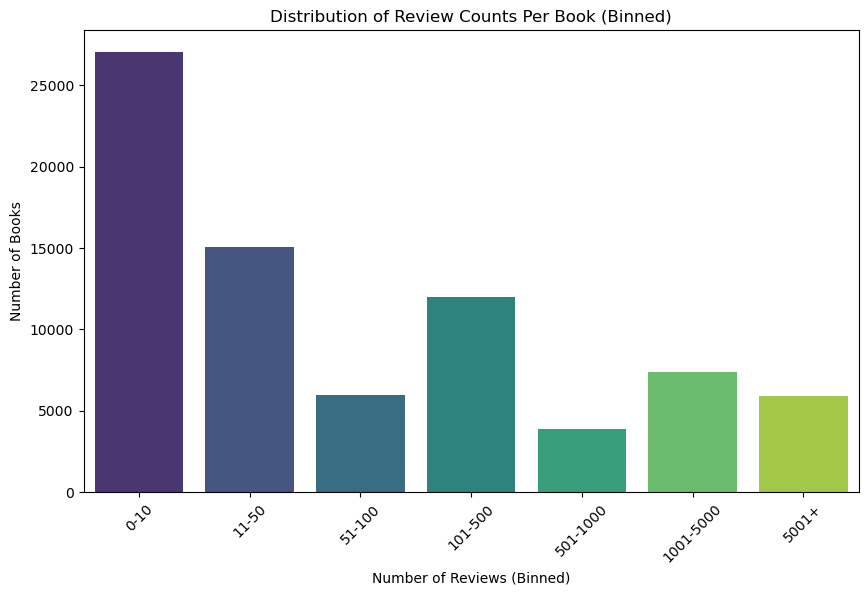

In [270]:
# clean the 'review_count' column
books_df['review_count'] = books_df['review_count'].astype(str).str.extract(r'(\d+)').astype(float)

# define bins for review counts
bins = [0, 10, 50, 100, 500, 1000, 5000, books_df['review_count'].max()]
labels = ['0-10', '11-50', '51-100', '101-500', '501-1000', '1001-5000', '5001+']

# bin the review counts and count books in each bin
books_df['review_count_bins'] = pd.cut(books_df['review_count'], bins=bins, labels=labels, right=True)
review_count_distribution = books_df['review_count_bins'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=review_count_distribution.index, y=review_count_distribution.values, palette="viridis")
plt.title('Distribution of Review Counts Per Book (Binned)')
plt.xlabel('Number of Reviews (Binned)')
plt.ylabel('Number of Books')
plt.xticks(rotation=45)
plt.show()


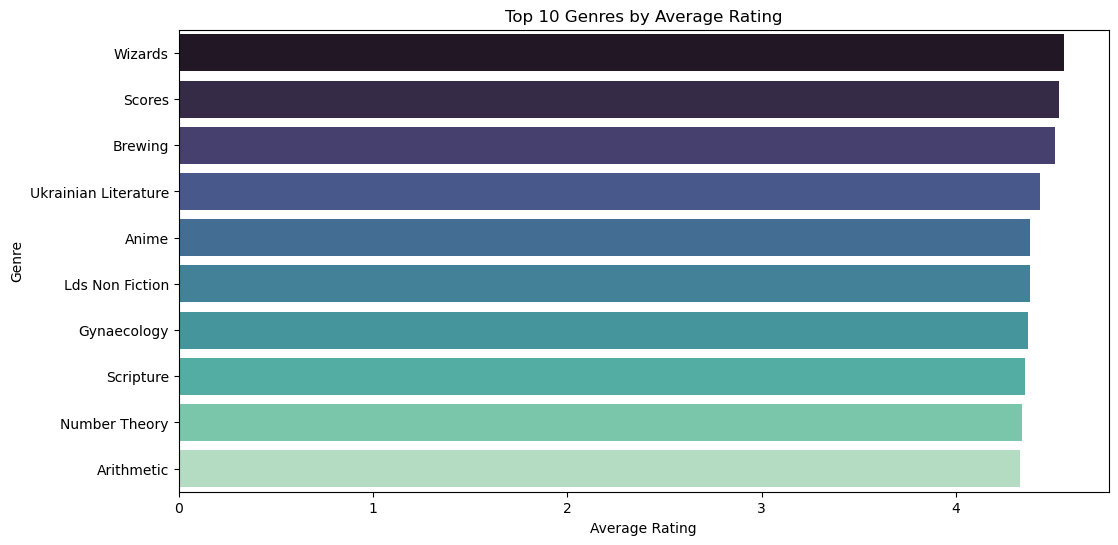

In [271]:
# merge book_genres, genres, and books to calculate average rating per genre
genre_avg_rating = book_genres_df.merge(genres_df, on='genre_id') \
    .merge(books_df[['isbn', 'average_rating']], on='isbn') \
    .groupby('name')['average_rating'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=genre_avg_rating.values, y=genre_avg_rating.index, palette='mako')
plt.title('Top 10 Genres by Average Rating')
plt.xlabel('Average Rating')
plt.ylabel('Genre')
plt.show()

In [273]:
print(books_df.columns)

Index(['isbn', 'isbn13', 'title', 'image_url', 'description', 'author',
       'num_pages', 'language', 'review_count', 'kindle_price', 'publish_date',
       'crawl_source', 'average_rating', 'series', 'review_count_bins'],
      dtype='object')


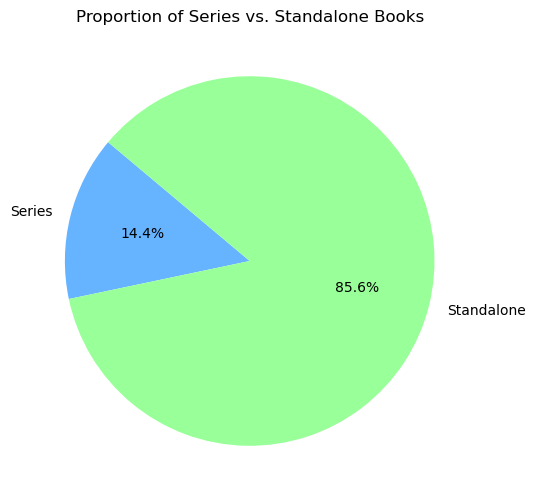

In [274]:
series_books = books_df['series'].notna().sum()
standalone_books = books_df['series'].isna().sum()

plt.figure(figsize=(8, 6))
plt.pie(
    [series_books, standalone_books],
    labels=['Series', 'Standalone'],
    autopct='%1.1f%%',
    startangle=140,
    colors=['#66b3ff', '#99ff99']
)
plt.title('Proportion of Series vs. Standalone Books')
plt.show()


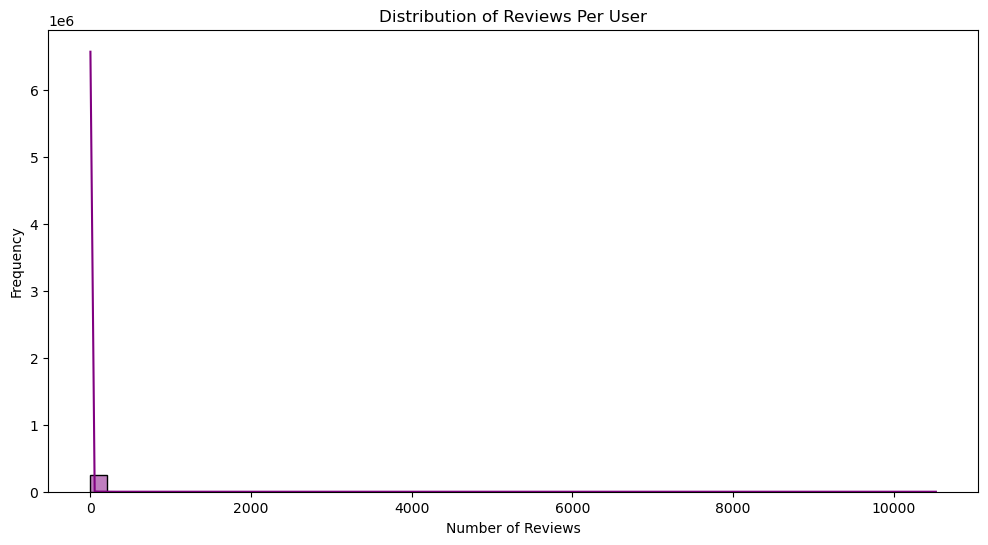

In [275]:
if 'user_id' in reviews_df.columns:
    user_reviews_count = reviews_df['user_id'].value_counts()

    plt.figure(figsize=(12, 6))
    sns.histplot(user_reviews_count, bins=50, kde=True, color='purple')
    plt.title('Distribution of Reviews Per User')
    plt.xlabel('Number of Reviews')
    plt.ylabel('Frequency')
    plt.show()


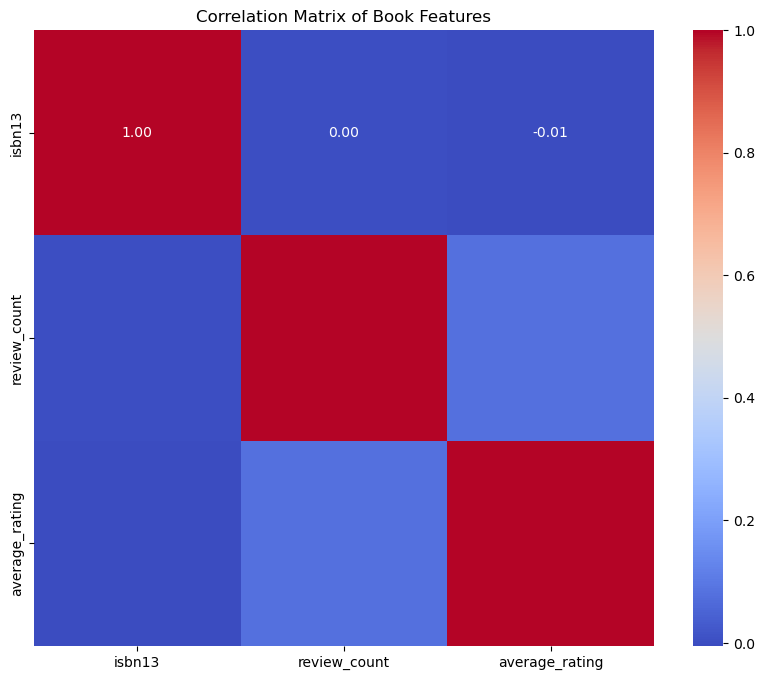

In [276]:
plt.figure(figsize=(10, 8))
sns.heatmap(books_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Book Features')
plt.show()


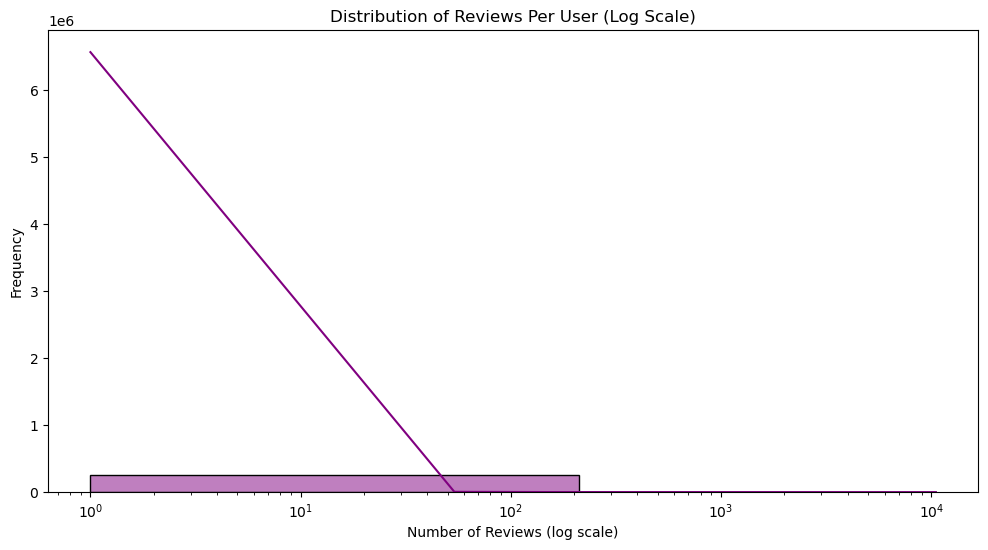

In [277]:
if 'user_id' in reviews_df.columns:
    user_reviews_count = reviews_df['user_id'].value_counts()

    plt.figure(figsize=(12, 6))
    sns.histplot(user_reviews_count, bins=50, kde=True, color='purple')
    
    # Set the x-axis to a logarithmic scale
    plt.xscale('log')
    
    plt.title('Distribution of Reviews Per User (Log Scale)')
    plt.xlabel('Number of Reviews (log scale)')
    plt.ylabel('Frequency')
    plt.show()


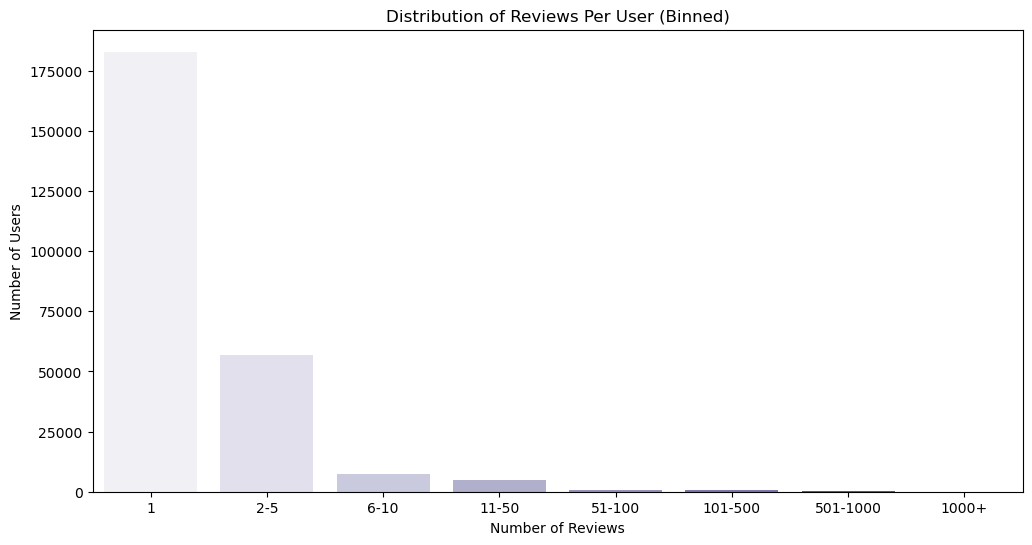

In [278]:
if 'user_id' in reviews_df.columns:
    user_reviews_count = reviews_df['user_id'].value_counts()

    # Define bins for the number of reviews
    bins = [0, 1, 5, 10, 50, 100, 500, 1000, user_reviews_count.max()]
    labels = ['1', '2-5', '6-10', '11-50', '51-100', '101-500', '501-1000', '1000+']
    
    # Create a new column for binned review counts
    user_reviews_count_bins = pd.cut(user_reviews_count, bins=bins, labels=labels, right=True)

    # Plot the distribution of users in each bin
    plt.figure(figsize=(12, 6))
    sns.countplot(x=user_reviews_count_bins, palette='Purples')

    plt.title('Distribution of Reviews Per User (Binned)')
    plt.xlabel('Number of Reviews')
    plt.ylabel('Number of Users')
    plt.show()


In [279]:
num_books = books_df.shape[0]
num_reviews = reviews_df.shape[0]
unique_users = reviews_df['user_id'].nunique() if 'user_id' in reviews_df.columns else None

reviews_per_user = num_reviews / unique_users if unique_users else None
reviews_per_book = num_reviews / num_books

# Print statistics
print(f"Number of books: {num_books}")
print(f"Number of reviews: {num_reviews}")
print(f"Number of unique users: {unique_users}")
print(f"Average reviews per user: {reviews_per_user:.2f}" if reviews_per_user else "User data not available")
print(f"Average reviews per book: {reviews_per_book:.2f}")

Number of books: 102561
Number of reviews: 845857
Number of unique users: 253687
Average reviews per user: 3.33
Average reviews per book: 8.25


In [286]:
books_df


,isbn,isbn13,title,image_url,description,author,num_pages,language,review_count,kindle_price,publish_date,crawl_source,average_rating,series,review_count_bins
0,1662528396,9.781663e+12,['Cruel Winter with You'],['https://images-na.ssl-images-amazon.com/imag...,"['For two former childhood friends, a blustery...",['Ali Hazelwood'],[73],['English'],11514.0,['0.99'],[1731398400000],['https://www.goodreads.com/book/show/22038945...,3.71,Under The Mistletoe Collection,5001+
1,0664266703,9.780664e+12,['The Purpose Gap: Empowering Communities of C...,['https://images-na.ssl-images-amazon.com/imag...,"[""In The Purpose Gap, Patrick Reyes reflects o...",['Patrick B. Reyes'],[256],['English'],12.0,['9.99'],[1615878000000],['https://www.goodreads.com/book/show/55334104...,4.13,NaN,11-50
2,166252823X,9.781663e+12,['All by My Elf'],['https://images-na.ssl-images-amazon.com/imag...,"['Secret crushes, spicy Christmas treats, hein...",['Olivia Dade'],[55],['English'],3892.0,['0.99'],[1731398400000],['https://www.goodreads.com/book/show/22038945...,2.61,Under The Mistletoe Collection,1001-5000
3,1400341124,9.781400e+12,['Mostly What God Does: Reflections on Seeking...,['https://images-na.ssl-images-amazon.com/imag...,"[""Mostly what God does is love you.\r\n\r\nIf ...",['Savannah Guthrie'],[302],['English'],726.0,['14.99'],[1708416000000],['https://www.goodreads.com/book/show/20021292...,4.34,NaN,501-1000
4,1662529376,9.781663e+12,['Only Santas in the Building'],['https://images-na.ssl-images-amazon.com/imag...,"['It’s beginning to look a lot like Christmas,...",['Alexis Daria'],[65],['English'],3047.0,['0.99'],[1731398400000],['https://www.goodreads.com/book/show/22038909...,3.39,Under The Mistletoe Collection,1001-5000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102556,0226100316,9.780226e+12,['Improvising Theory: Process and Temporality ...,['https://images-na.ssl-images-amazon.com/imag...,['Scholars have long recognized that ethnograp...,['Allaine Cerwonka'],[203],['English'],10.0,['27.99'],[1184482800000],['https://www.goodreads.com/book/show/250000.I...,4.00,NaN,0-10
102557,0451169530,9.780451e+12,NaN,NaN,NaN,['Stephen King'],NaN,NaN,31307.0,NaN,NaN,['https://www.goodreads.com/book/show/87591651...,4.35,NaN,5001+
102558,0140512691,9.780141e+12,['The Penguin Dictionary of 19th-Century Histo...,['https://images-na.ssl-images-amazon.com/imag...,['Presents a comprehensive review of the polit...,['John Belchem'],[768],['English'],0.0,NaN,[862470000000],['https://www.goodreads.com/book/show/249969.T...,4.00,NaN,NaN
102559,0897332881,9.780897e+12,NaN,NaN,NaN,['Bruce Myles'],NaN,NaN,77.0,NaN,NaN,['https://www.goodreads.com/book/show/249831.N...,4.18,NaN,51-100


In [288]:
book_genres_df


,isbn,isbn13,genre_id
0,1662528396,9.781663e+12,224
1,1662528396,9.781663e+12,895
2,1662528396,9.781663e+12,721
3,1662528396,9.781663e+12,404
4,1662528396,9.781663e+12,43
...,...,...,...
317785,158062684X,9.781581e+12,717
317786,0226100316,9.780226e+12,857
317787,0226100316,9.780226e+12,834
317788,0140512691,9.780141e+12,662


In [289]:
genres_df


,genre_id,name
0,1,14th Century
1,2,Southern
2,3,Agriculture
3,4,Australia
4,5,Mormonism
...,...,...
1017,1018,Basketball
1018,1019,Witches
1019,1020,Native American
1020,1021,African Literature


In [290]:
reviews_df


,isbn,isbn13,user_id,rating_score
0,0345465296,9780345465290,1742824,5.0
1,0345465296,9780345465290,9180313,5.0
2,0345465296,9780345465290,36153170,5.0
3,0345465296,9780345465290,22819383,4.0
4,0345465296,9780345465290,8845508,5.0
...,...,...,...,...
845852,0399155341,9780399155345,125982174,5.0
845853,0439554934,9780439554930,125982174,5.0
845854,0316015849,9780316015844,125982174,5.0
845855,0062024035,9780062024039,125982174,5.0


In [291]:
series_df


,series_id,name
0,1,Addicted to Him
1,2,Sky and Sea
2,3,Chaosium's Call of Cthulhu books
3,4,The Starkin Crown
4,5,Matched
...,...,...
5944,5945,Mike Martin
5945,5946,The Liveship Traders
5946,5947,Matthew Hope
5947,5948,Robinson Crusoe


In [292]:
users_df

,user_id,name,profile_url,total_ratings,total_reviews,avg_rating,image_url
0,19185877,acacia,https://www.goodreads.com/user/show/19185877-a...,835,59,4.30,https://images.gr-assets.com/users/1597698907p...
1,169105231,kelli,https://www.goodreads.com/user/show/169105231-...,384,1,3.60,https://images.gr-assets.com/users/1692562817p...
2,38623456,steph,https://www.goodreads.com/user/show/38623456-s...,365,0,3.33,https://s.gr-assets.com/assets/nophoto/user/f_...
3,8829118,mindy,https://www.goodreads.com/user/show/8829118-mi...,59,2,3.69,NaN
4,179297432,kourtney,https://www.goodreads.com/user/show/179297432-...,64,11,4.28,NaN
...,...,...,...,...,...,...,...
23587,502678,Gail,https://www.goodreads.com/user/show/502678-gail,0,0,0.00,https://i.gr-assets.com/images/S/compressed.ph...
23588,31968163,The Overflowing Inkwell,https://www.goodreads.com/user/show/31968163-t...,0,0,0.00,https://i.gr-assets.com/images/S/compressed.ph...
23589,43122073,Linda,https://www.goodreads.com/user/show/43122073-l...,0,0,0.00,https://i.gr-assets.com/images/S/compressed.ph...
23590,87271128,Khava,https://www.goodreads.com/user/show/87271128-k...,0,0,0.00,https://i.gr-assets.com/images/S/compressed.ph...


In [295]:
books_df.to_csv('./clean/new/cleaned_books_data.csv', index=False)
book_genres_df.to_csv('./clean/new/cleaned_book_genres_data.csv', index=False)
genres_df.to_csv('./clean/new/cleaned_genres_data.csv', index=False)
reviews_df.to_csv('./clean/new/cleaned_reviews_data.csv', index=False)
series_df.to_csv('./clean/new/cleaned_series_data.csv', index=False)
users_df.to_csv('./clean/new/cleaned_users_data.csv', index=False)